Saving flipkart_customer_data_2000.csv to flipkart_customer_data_2000.csv
DATASET INFORMATION

Dataset Shape: (2000, 2)

Columns: Index(['instruction', 'intent'], dtype='object')


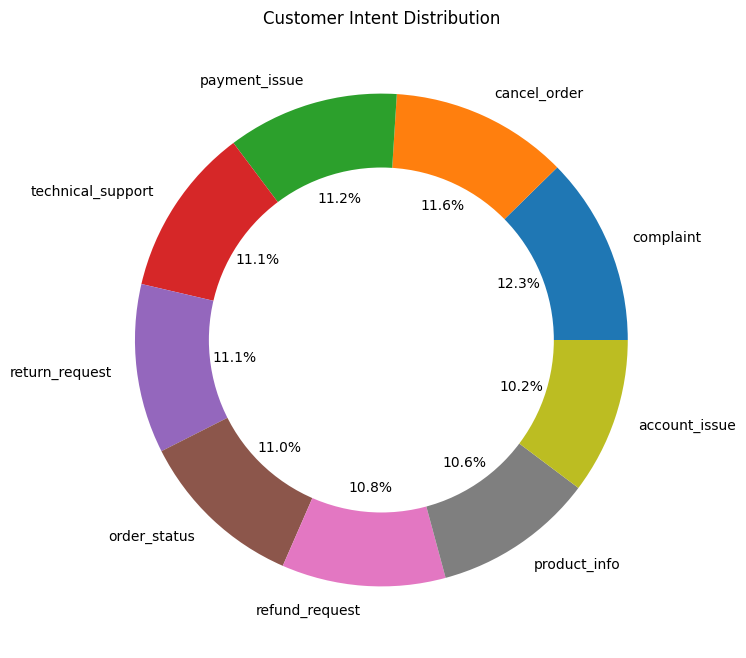

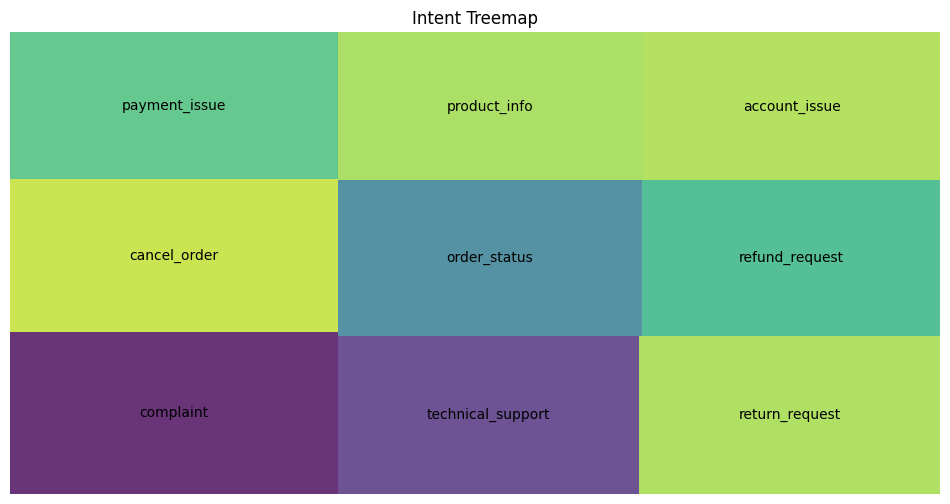

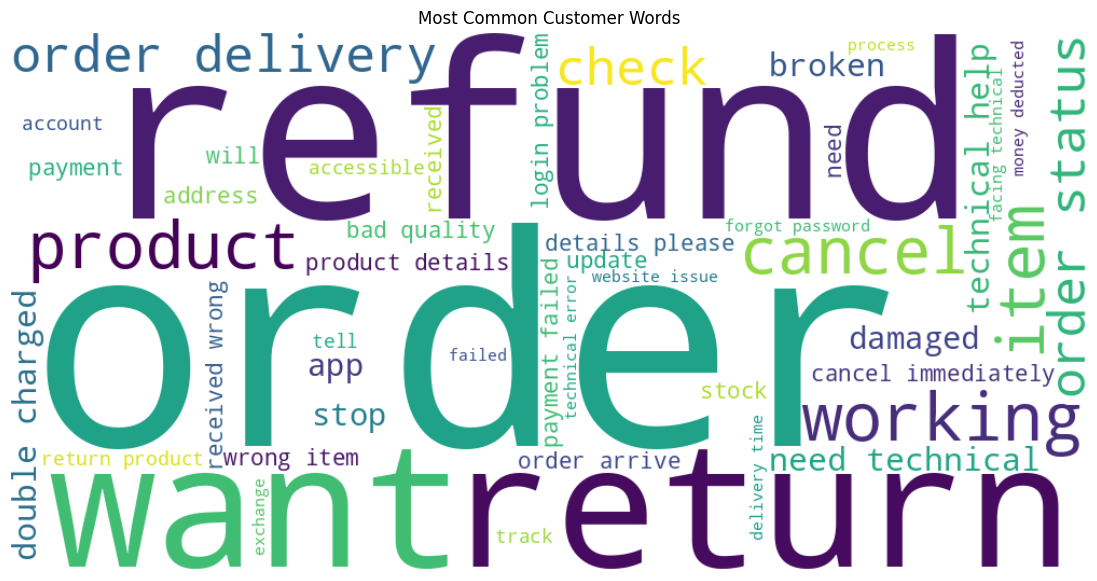

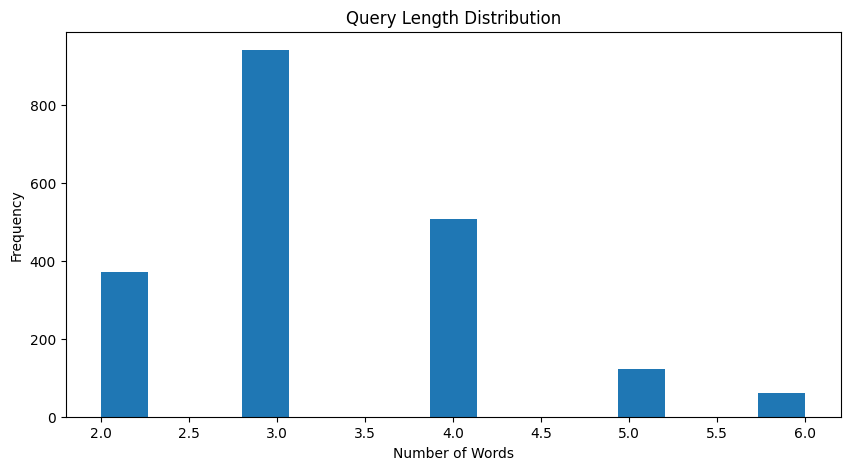


MODEL PERFORMANCE

Accuracy: 1.0

Classification Report:

                   precision    recall  f1-score   support

    account_issue       1.00      1.00      1.00        45
     cancel_order       1.00      1.00      1.00        48
        complaint       1.00      1.00      1.00        55
     order_status       1.00      1.00      1.00        31
    payment_issue       1.00      1.00      1.00        49
     product_info       1.00      1.00      1.00        45
   refund_request       1.00      1.00      1.00        47
   return_request       1.00      1.00      1.00        41
technical_support       1.00      1.00      1.00        39

         accuracy                           1.00       400
        macro avg       1.00      1.00      1.00       400
     weighted avg       1.00      1.00      1.00       400



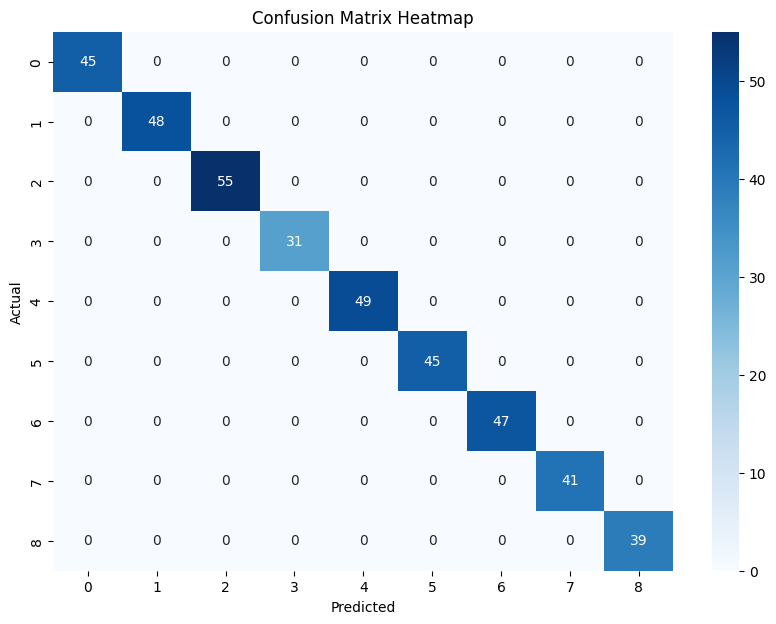

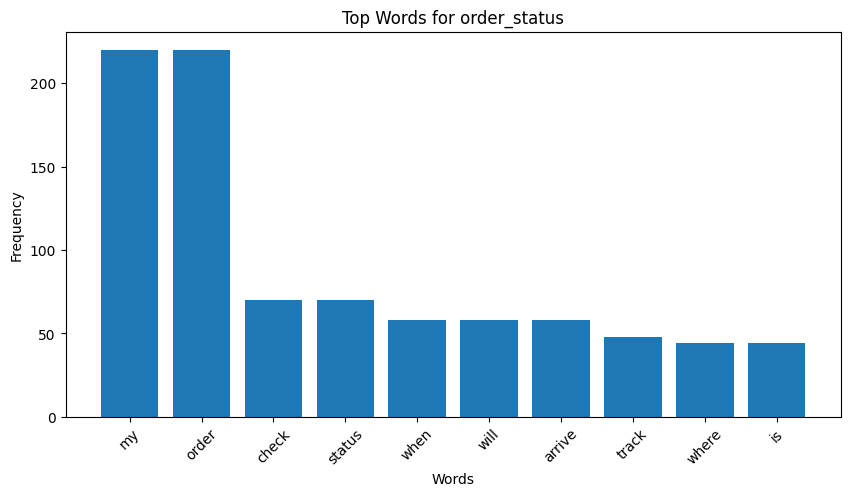

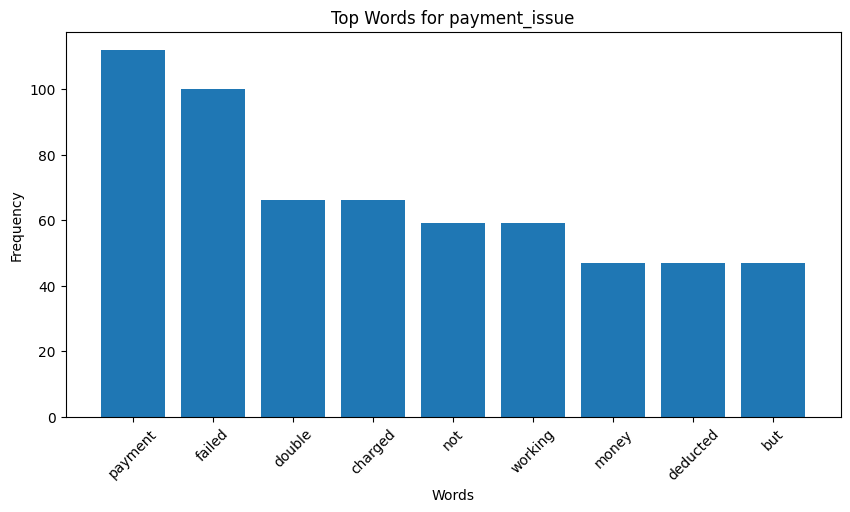

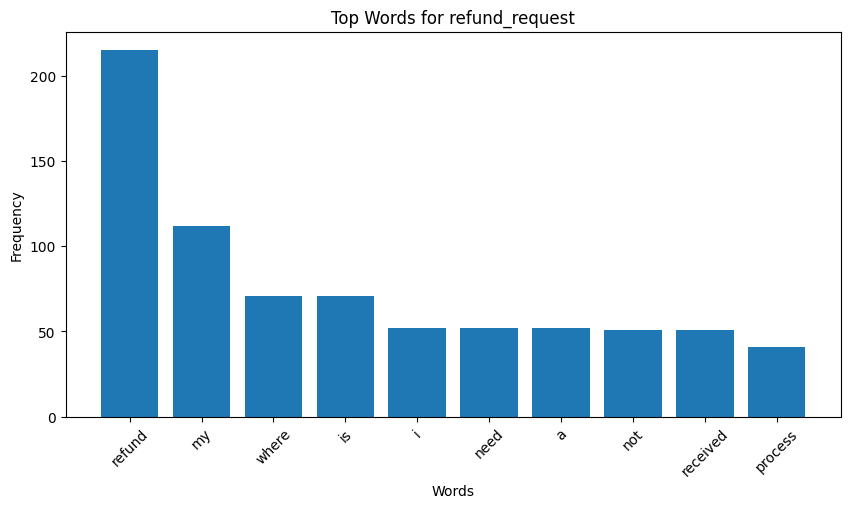

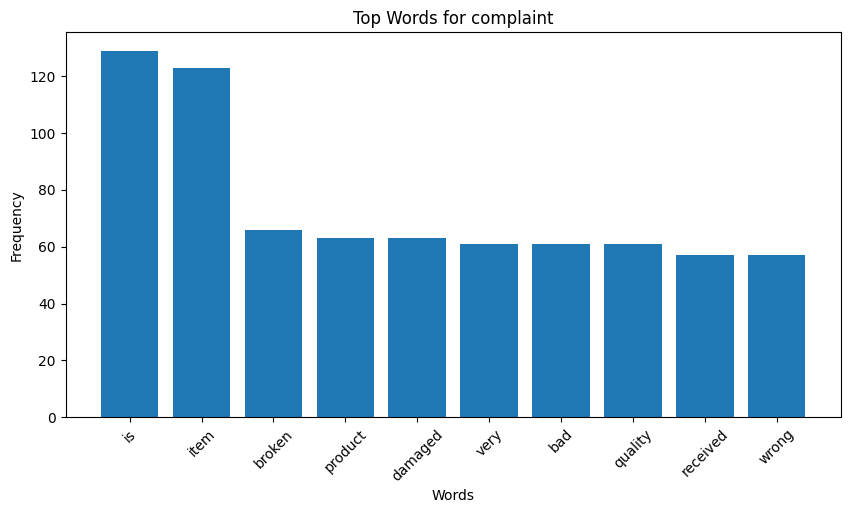

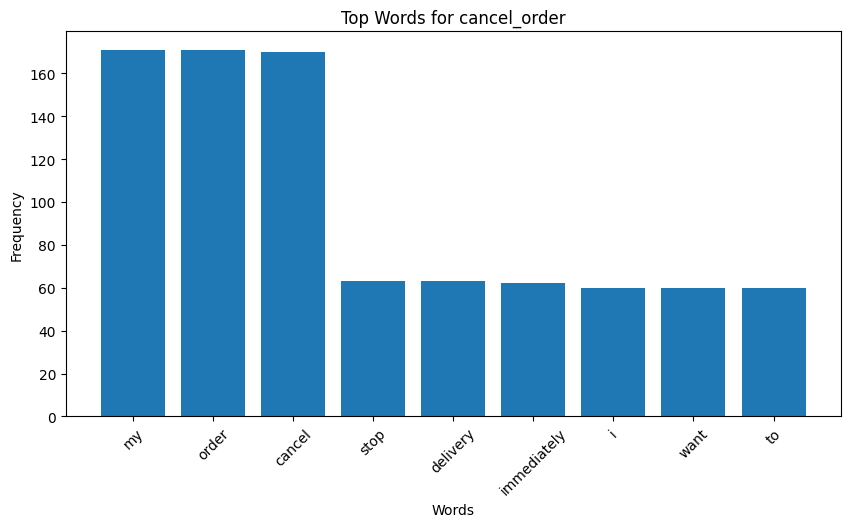

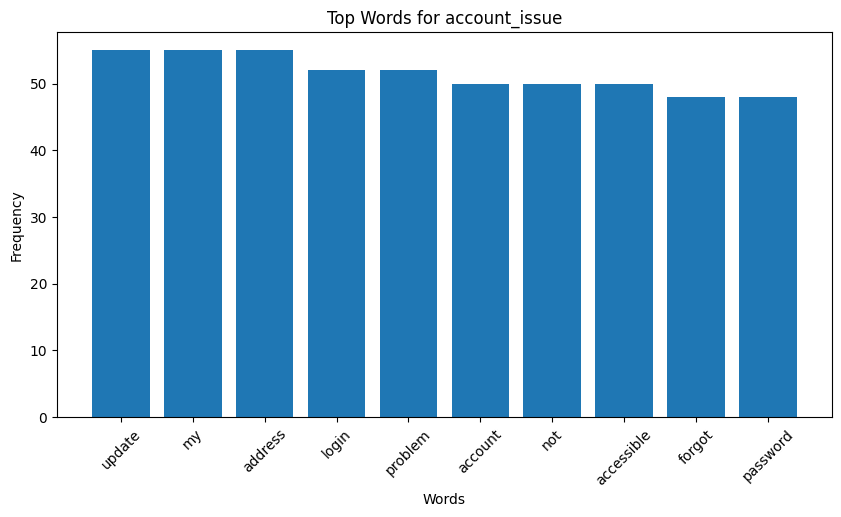

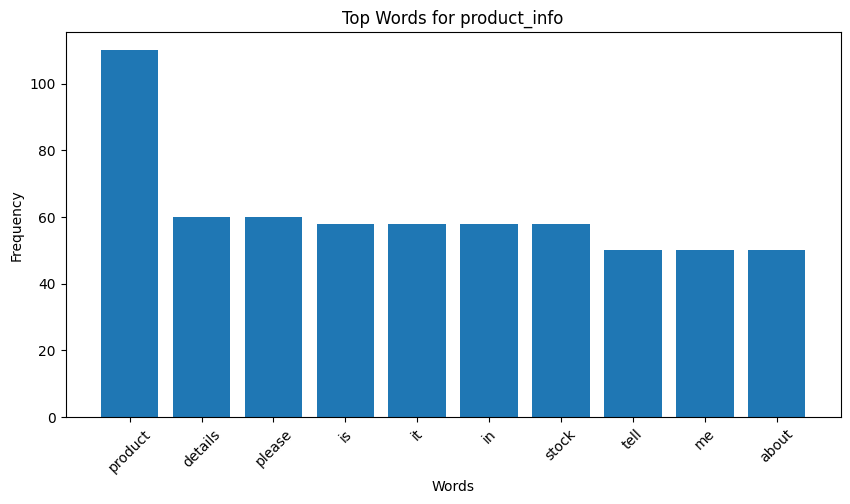

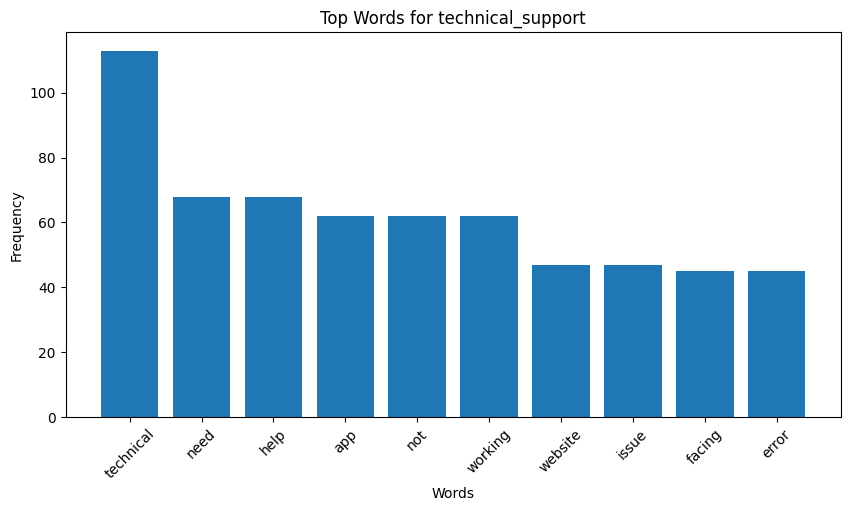

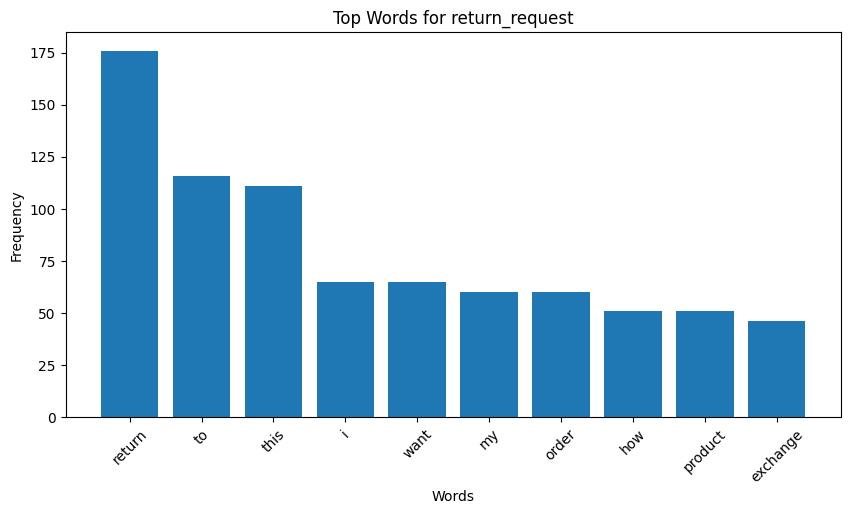

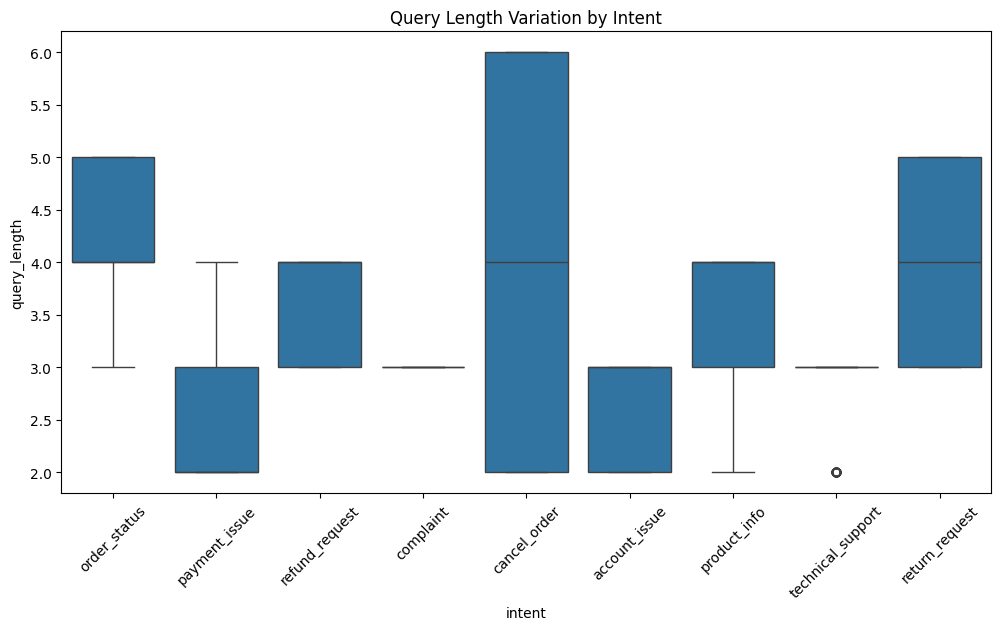

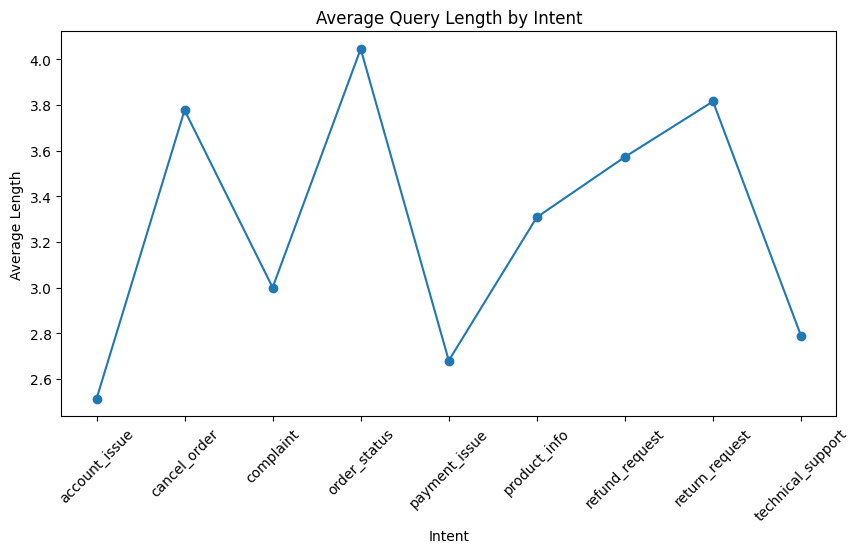

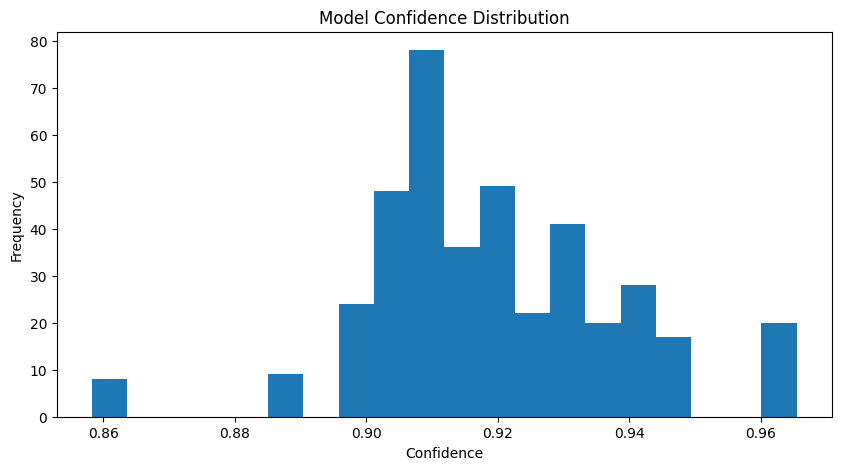

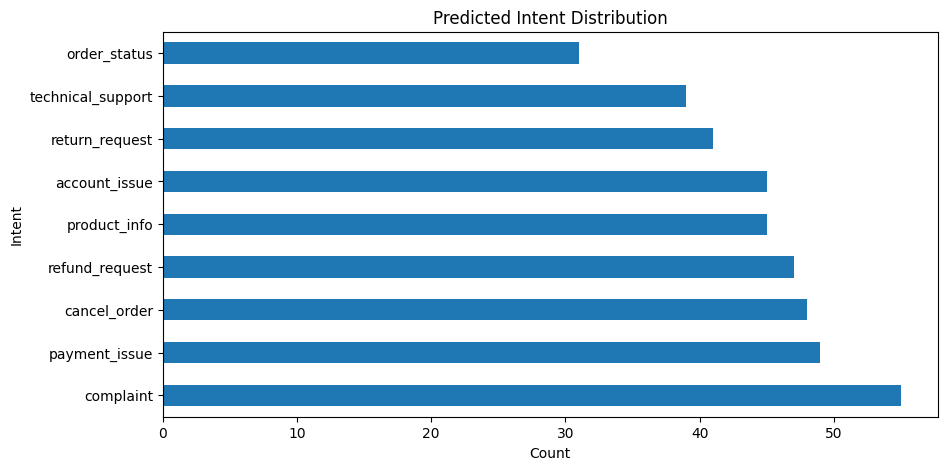


MISCLASSIFIED EXAMPLES

No Misclassifications Found

SAMPLE PREDICTIONS
       Customer Query   Predicted Intent
0       I want refund     refund_request
1     Cancel my order       cancel_order
2      Payment failed      payment_issue
3   Where is my order       order_status
4  App is not working  technical_support

PROJECT EXECUTED SUCCESSFULLY

All visualizations generated.
Model trained and evaluated.
Customer intent classification completed.


In [1]:
# =========================================
# CUSTOMER INTENT CLASSIFICATION PROJECT
# WITH ADVANCED VISUALIZATIONS
# =========================================

# =========================================
# 1. INSTALL REQUIRED LIBRARIES
# =========================================
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud squarify

# =========================================
# 2. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================
# 3. UPLOAD DATASET
# =========================================
from google.colab import files
uploaded = files.upload()

# =========================================
# 4. LOAD DATASET
# =========================================
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("=================================")
print("DATASET INFORMATION")
print("=================================")

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)

# =========================================
# 5. PREPARE DATA
# =========================================
df = df[['instruction', 'intent']]
df.rename(columns={'instruction': 'query'}, inplace=True)

# =========================================
# 6. TEXT CLEANING
# =========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_query'] = df['query'].apply(clean_text)

# =========================================
# 7. QUERY LENGTH FEATURE
# =========================================
df['query_length'] = df['clean_query'].apply(
    lambda x: len(x.split())
)

# =========================================
# 8. VISUALIZATION 1
# DONUT CHART - INTENT DISTRIBUTION
# =========================================
intent_counts = df['intent'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    intent_counts,
    labels=intent_counts.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Customer Intent Distribution")
plt.show()

# =========================================
# 9. VISUALIZATION 2
# TREEMAP
# =========================================
plt.figure(figsize=(12,6))

squarify.plot(
    sizes=intent_counts.values,
    label=intent_counts.index,
    alpha=0.8
)

plt.axis('off')

plt.title("Intent Treemap")
plt.show()

# =========================================
# 10. VISUALIZATION 3
# WORD CLOUD
# =========================================
text = " ".join(df['clean_query'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Most Common Customer Words")

plt.show()

# =========================================
# 11. VISUALIZATION 4
# QUERY LENGTH DISTRIBUTION
# =========================================
plt.figure(figsize=(10,5))

plt.hist(df['query_length'], bins=15)

plt.title("Query Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

# =========================================
# 12. TRAIN TEST SPLIT
# =========================================
X = df['clean_query']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# 13. TF-IDF VECTORIZATION
# =========================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

# =========================================
# 14. MODEL TRAINING
# =========================================
model = LogisticRegression(max_iter=200)

model.fit(X_train_vec, y_train)

# =========================================
# 15. MODEL PREDICTIONS
# =========================================
y_pred = model.predict(X_test_vec)

# =========================================
# 16. MODEL PERFORMANCE
# =========================================
print("\n=================================")
print("MODEL PERFORMANCE")
print("=================================")

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================================
# 17. VISUALIZATION 5
# CONFUSION MATRIX HEATMAP
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Heatmap")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================
# 18. VISUALIZATION 6
# TOP WORDS PER INTENT
# =========================================
for intent in df['intent'].unique():

    text = " ".join(
        df[df['intent'] == intent]['clean_query']
    )

    words = text.split()

    common_words = Counter(words).most_common(10)

    words_list = [w[0] for w in common_words]

    counts = [w[1] for w in common_words]

    plt.figure(figsize=(10,5))

    plt.bar(words_list, counts)

    plt.title(f"Top Words for {intent}")

    plt.xlabel("Words")

    plt.ylabel("Frequency")

    plt.xticks(rotation=45)

    plt.show()

# =========================================
# 19. VISUALIZATION 7
# BOXPLOT
# =========================================
plt.figure(figsize=(12,6))

sns.boxplot(
    x='intent',
    y='query_length',
    data=df
)

plt.xticks(rotation=45)

plt.title("Query Length Variation by Intent")

plt.show()

# =========================================
# 20. VISUALIZATION 8
# LINE PLOT
# =========================================
avg_len = df.groupby(
    'intent'
)['query_length'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    avg_len.index,
    avg_len.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Average Query Length by Intent")

plt.xlabel("Intent")

plt.ylabel("Average Length")

plt.show()

# =========================================
# 21. VISUALIZATION 9
# MODEL CONFIDENCE DISTRIBUTION
# =========================================
probs = model.predict_proba(X_test_vec)

confidence = probs.max(axis=1)

plt.figure(figsize=(10,5))

plt.hist(confidence, bins=20)

plt.title("Model Confidence Distribution")

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.show()

# =========================================
# 22. VISUALIZATION 10
# PREDICTED INTENT DISTRIBUTION
# =========================================
plt.figure(figsize=(10,5))

pd.Series(y_pred).value_counts().plot(
    kind='barh'
)

plt.title("Predicted Intent Distribution")

plt.xlabel("Count")

plt.ylabel("Intent")

plt.show()

# =========================================
# 23. MISCLASSIFIED EXAMPLES
# =========================================
misclassified = pd.DataFrame({
    'Query': X_test,
    'Actual': y_test,
    'Predicted': y_pred
})

misclassified = misclassified[
    misclassified['Actual']
    !=
    misclassified['Predicted']
]

print("\n=================================")
print("MISCLASSIFIED EXAMPLES")
print("=================================")

if misclassified.empty:
    print("\nNo Misclassifications Found")
else:
    print(misclassified.head(10))

# =========================================
# 24. SAMPLE PREDICTIONS
# =========================================
sample_queries = [
    "I want refund",
    "Cancel my order",
    "Payment failed",
    "Where is my order",
    "App is not working"
]

cleaned = [
    clean_text(q)
    for q in sample_queries
]

vec = vectorizer.transform(cleaned)

predictions = model.predict(vec)

results = pd.DataFrame({
    "Customer Query": sample_queries,
    "Predicted Intent": predictions
})

print("\n=================================")
print("SAMPLE PREDICTIONS")
print("=================================")

print(results)

# =========================================
# 25. FINAL MESSAGE
# =========================================
print("\n=================================")
print("PROJECT EXECUTED SUCCESSFULLY")
print("=================================")
print("\nAll visualizations generated.")
print("Model trained and evaluated.")
print("Customer intent classification completed.")